# Exploration de la qualité des données

Nous devons vérifier si les données collectées sont suffisamment fiables et pertinentes pour notre sujet.

## 0. Import de fonctions utiles à l'importation des données

Avant de procéder à l'acquisition des données, il est essentiel de configurer notre environnement de travail. Dans une optique de **reproductibilité** et de **clarté du code**, la logique technique (les fonctions de téléchargement) a été déportée dans un dossier dédié nommé `/fonctions`, composé de fichiers Python. 

La cellule suivante initialise cette connexion en ajoutant le dossier des scripts au chemin système de Python et en important l'ensemble des dépendances nécessaires.

In [4]:
import sys
import os
import pandas as pd
from pathlib import Path

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions/exploration
sys.path.append(os.path.abspath("../fonctions/exploration"))

%load_ext autoreload
%autoreload 2

# On importe toutes les fonctions dans le fichier imports.py
from transfermarkt import *
from fbref import *
from statsbomb import *
from football_data import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Transfermarkt - data qualité

Avant d'intégrer les statistiques de performance, il est impératif de valider la fiabilité de notre variable cible : la **valeur marchande**. 
Cette phase permet de comprendre la structure du marché, d'identifier les segments de joueurs et de nettoyer les données pour garantir la précision du futur modèle prédictif.

### 0. Source des données et traçabilité
Afin de garantir la reproductibilité de cette analyse, les données sont extraites directement via l'API Kaggle. 

* **Dataset :** [Football Data from Transfermarkt](https://www.kaggle.com/datasets/davidcariboo/player-scores)
* **Identifiant :** `davidcariboo/player-scores`

In [5]:
identifiant = "davidcariboo/player-scores"
date_update = get_kaggle_dataset_last_update(identifiant)

Dataset trouvé : davidcariboo/player-scores
Dernière mise à jour : 2026-05-08 06:34:01.597000


### 1. Analyse Exploratoire de la Population

L'examen initial des distributions révèle trois facteurs principaux concernant la valorisation des joueurs :

* **Distribution des valeurs marchandes :** On observe un comportement assez particulier. La majorité des joueurs se situe sous les 5M€, tandis que très peu de joueurs dépassent les 100M€. Cette asymétrie impose une approche logarithmique pour la modélisation.
* **Courbe des âges :** La distribution suit une courbe de Gauss centrée sur **25-28 ans**. La valeur marchande étant liée au potentiel de revente et à la qualité physique, l'âge sera une variable explicative non-linéaire majeure.
* **Segmentation par ligue (Big 5) :** Les boxplots confirment un marché à plusieurs vitesses. La **Premier League** affiche non seulement la médiane la plus haute mais aussi la plus forte concentration de joueurs plus chers (les outliers). À talent égal, le facteur "Ligue" devrait influencer drastiquement le prix final.

In [4]:
# Chargement des fichiers
df_players = pd.read_csv("../data/transfermarkt_datasets/players.csv")
df_clubs = pd.read_csv("../data/transfermarkt_datasets/clubs.csv")

# Appel de la fonction avec les deux dataframes
plot_transfermarkt_quality(df_players, df_clubs)

NameError: name 'plot_transfermarkt_quality' is not defined

### 2. Fraîcheur et Pertinence Temporelle

Le graphique des dates de dernières évaluations est un indicateur de fiabilité. En effet, une partie du dataset contient des prix n'ayant pas été mis à jour depuis plusieurs années (2012-2022). Ces données ne sont plus analysables statistiquement car elles ne correspondent plus aux performances actuelles.

In [10]:
# Chargement de l'historique des valeurs marchandes
df_valuations = pd.read_csv("../data/transfermarkt_datasets/player_valuations.csv")

# Convertir la colonne date en format datetime
get_latest_player_valuations(df_valuations, plot_freshness=True)

NameError: name 'get_latest_player_valuations' is not defined

### 3. Diagnostic de l'Intégrité des Données
Le nettoyage technique repose sur trois vérifications critiques :

* **Valeurs manquantes (NaN) :** 18% des joueurs n'ont pas de valeur cible (valeur marchande) et sont donc exclus. Les statistiques internationales manquantes sont imputées à `0` (joueurs non-sélectionnés).
* **Doublons :** Seuls 2 doublons (Nom/Date de naissance) ont été détectés, prouvant la robustesse du dataset.
* **Intégrité référentielle (orphelins) :** 135 joueurs possèdent un historique de prix mais aucune fiche de profil associée.

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\exploration_transfermarkt.py:202: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.index, y=missing_pct.values, palette="Reds_r")


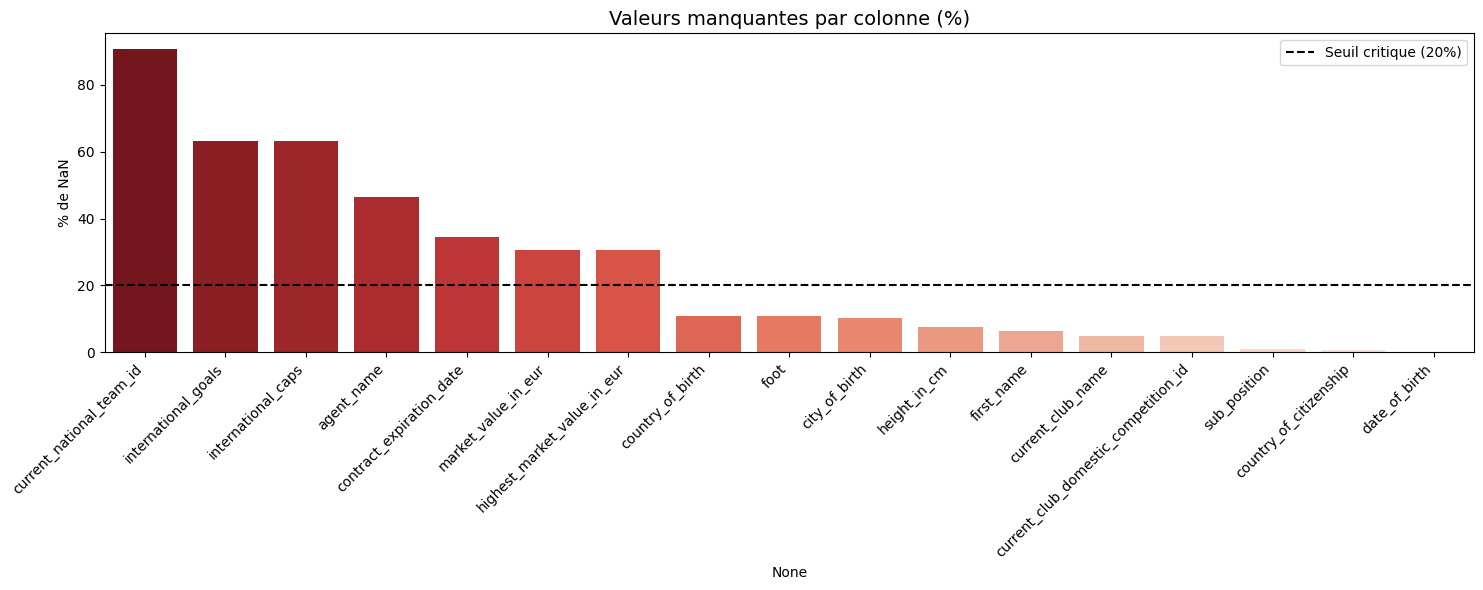

In [6]:
# 2. Analyse des valeurs manquantes (Contrats et Cible)
check_all_missing_values(df_players)

In [7]:
check_player_duplicates(df_players)

2 doublons potentiels détectés (même nom et date de naissance).


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
23634,398057,João,Ricciulli,João Ricciulli,2018,1038,joao-ricciulli,Guinea-Bissau,Bissau,Guinea-Bissau,...,Evlon Sports & Mgmt,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/joao-ricciulli...,IT1,UC Sampdoria,25000.0,100000.0
26111,461923,João,Ricciulli,João Ricciulli,2022,2420,joao-ricciulli,NaN,Bissau,NaN,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/joao-ricciulli...,PO1,Vitória Sport Clube,100000.0,100000.0


In [8]:
# On vérifie l'intégrité avant d'aller plus loin

df_market_final = pd.read_csv("../data/transfermarkt_datasets/player_valuations.csv")

orphans_list = check_referential_integrity(df_players, df_market_final)

Analyse de l'intégrité référentielle :
- Joueurs dans le fichier Profil : 47623
- Joueurs dans le fichier Valuations : 33025
----------------------------------------
Intégrité parfaite : Tous les prix sont reliés à un profil joueur.


## 2. FBref - data qualité

### 0. Source des données et traçabilité
Afin de garantir la reproductibilité de cette analyse, les données sont extraites directement via l'API Kaggle. 

* **Dataset :** [Football Players Stats (2025-2026)](https://www.kaggle.com/datasets/hubertsidorowicz/football-players-stats-2025-2026)
* **Identifiant :** `hubertsidorowicz/football-players-stats-2025-2026`

In [9]:
# L'identifiant du Kaggle
identifiant = 'hubertsidorowicz/football-players-stats-2025-2026'

# La date de dernière mise à jour
date_update = get_kaggle_dataset_last_update(identifiant)

Dataset trouvé : hubertsidorowicz/football-players-stats-2025-2026
Dernière mise à jour : 2026-04-28 08:52:47.730000


### 1. Filtrage de représentativité

Le dataset FBref brut contient l'intégralité des joueurs ayant foulé la pelouse, même pour quelques secondes. Pour garantir la robustesse statistique de notre modèle, un filtrage sur le temps de jeu est impératif.

Nous avons fixé un minimum de **450 minutes jouées** (l'équivalent de 5 matchs complets). Ce filtre réduit le dataset de **30.7%**, passant de 2 751 à 1 907 joueurs. Bien que la perte de données semble importante, elle est nécessaire pour éliminer le bruit statistique.

Avant filtrage, des joueurs comme *Marin Ljubicic* affichaient un ratio de **8.18 buts / 90 min** (car il a marqué 2 buts en seulement 22 minutes). En conservant ces profils, on prendrait en compte des corrélations erronées, pensant que l'efficacité est décorrélée du temps de jeu réel.

Enfin, nous avons isolé **1 777 joueurs de champ** et **130 gardiens de but**. Cette séparation est fondamentale car les métriques de performance (tacles, buts vs arrêts, clean sheets) ne sont pas comparables mathématiquement.

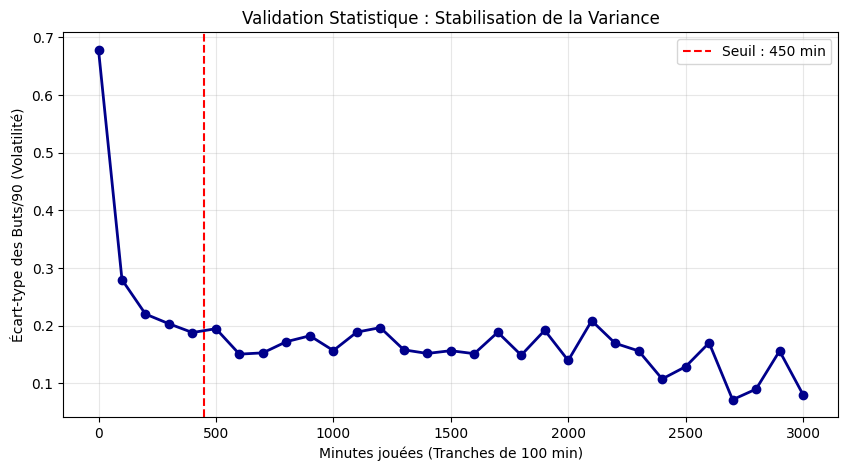

Preuve mathématique : Réduction du bruit de 66.3%
FILTRAGE TERMINÉ
- Joueurs initiaux : 2761
- Joueurs conservés : 1927 (Soit 1793 joueurs de champ)


In [10]:
# Chargement initial
df_fbref = pd.read_csv("../data/fbref_datasets/players_data-2025_2026.csv")

# Appel de la fonction
df_field, df_keepers = process_fbref_performance(df_fbref, min_minutes_played=450)

### 2. Analyse des valeurs manquantes

Le dataset FBref original est une agrégation complexe de plusieurs rapports (Standard, Shooting, Passing, etc.), ce qui génère une redondance massive d'informations et de nombreuses cellules vides.

Nous pouvons donc percevoir un grand nombre de variables ayant au moins 80% de valeurs manquantes.


La majorité des variables affichant plus de 80% de valeurs manquantes sont préfixées par _keeper (ex: GA, Saves, Save%, CS). Cela s'explique par le fait que ces statistiques ne concernent que les gardiens de but, qui ne représentent qu'une petite partie des joueurs présents dans le dataset global.

De plus, certaines colonnes comme PKsv (Penalties saved) ou PKm (Penalties missed) sont quasi vides car elles dépendent d'événements rares qui ne se produisent pas pour la majorité des joueurs au cours d'une saison.

Enfin, sur le Top 25 des variables les plus incomplètes, 24 dépassent le seuil critique de 80% de données manquantes, rendant ces colonnes inexploitables pour un modèle de machine learning global sans un traitement spécifique (segmentation par poste).

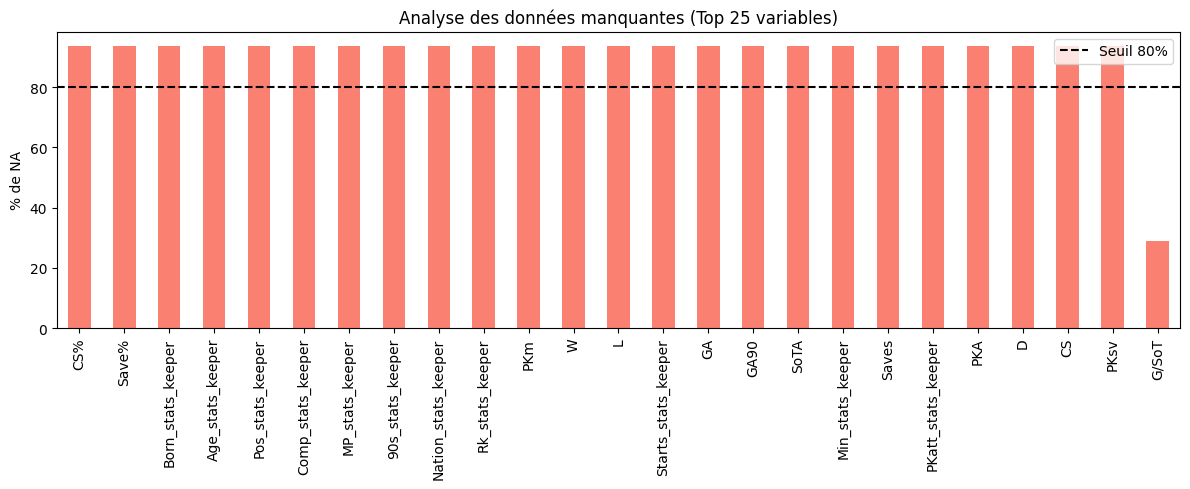

In [11]:
# Utilisation de la fonction sur tes joueurs de champ déjà filtrés
prune_fbref_columns(df_fbref, threshold=0.80)

### 3. Intégrité et unicité

Dans le dataset FBref, un joueur ayant changé de club ou ayant été prêté durant la saison apparaît sur plusieurs lignes (une entrée par club). 

Sans traitement, ces joueurs sont comptabilisés comme deux entités distinctes avec des statistiques partielles. Par exemple, **Simon Adingra** possédait deux lignes (une avec Sunderland, une avec Monaco) avec des volumes de jeu et des buts différents.

Nous avons identifié **26 joueurs** présentant ce cas de figure. Afin de garantir la représentativité de la performance, nous avons appliqué une règle de sélection stricte : seule la ligne présentant le **temps de jeu le plus élevé** est conservée.

Le volume est passé de 2761 à **2609 lignes**. Cette étape assure l'atomicité du dataset : **un joueur = une ligne**.

In [12]:
# On applique la résolution sur le dataset nettoyé
df_fbref_final = resolve_player_duplicates(df_fbref)

Joueurs avec plusieurs lignes (transferts/doublons) : 151
Bilan de l'unicité :
- Lignes traitées : 2761
- Lignes après dédoublonnage : 2609
- 'Doublons de transfert' supprimés : 152
----------------------------------------


### 4. Normalisation des Types et Formats

Pour que les données de performance soient exploitables par nos algorithmes et compatibles avec le dataset Transfermarkt, nous avons procédé à une normalisation structurelle.

En ce qui concerne l'âge, le format textuel de FBref (ex: `27-125`) a été transformé en format **float64**. Cette conversion est indispensable pour inclure l'âge comme variable quantitative dans nos futurs modèles de régression.

Les valeurs manquantes ont quant-à-elles été remplacés par **0**. Dans le contexte du football, une absence de donnée sur un tir ou une passe signifie que l'action n'a pas eu lieu, et non que l'information est inconnue.

Ainsi, le dataset final ne contient plus **aucune valeur manquante (0 NaN)** sur les 47 colonnes conservées, garantissant une stabilité totale pour les calculs matriciels à venir.

In [13]:
# Application de la normalisation sur ton dataset unique
df_fbref_final = normalize_fbref_formats(df_fbref_final)

# Vérification rapide
print(f"Format final de la colonne Age : {df_fbref_final['Age'].dtype}")

Normalisation des formats terminée.
- Colonnes numériques imputées (0) : 81
- Colonnes texte imputées (Unknown) : 21
- Valeurs manquantes totales restantes : 0
Format final de la colonne Age : float64


### 5. Cohérence statistique

La dernière étape de notre protocole de nettoyage consiste à valider les valeurs extrêmes pour s'assurer qu'elles reflètent la réalité sportive et non une anomalie de saisie.

L'analyse des boxplots révèle des outliers significatifs sur le nombre de buts et de tirs. Après vérification, ces points correspondent aux "Top Players" mondiaux. Ces données sont conservées car elles sont essentielles pour que l'IA apprenne à valoriser ces joueurs atypiques.

Au niveau d l'âge, une valeur aberrante a été détectée (0 année). Cela est probablement dû à une valeur manquantes remplacée par un 0. La population étudiée est alors hormis cet individu cohérente avec les standards du football professionnel.

Enfin, en l'absence du filtre initial de 450 minutes, les ratios par 90 minutes (Gls/90, Sh/90) ne sont pas stabilisés et présentent des pics mathématiques artificiels.

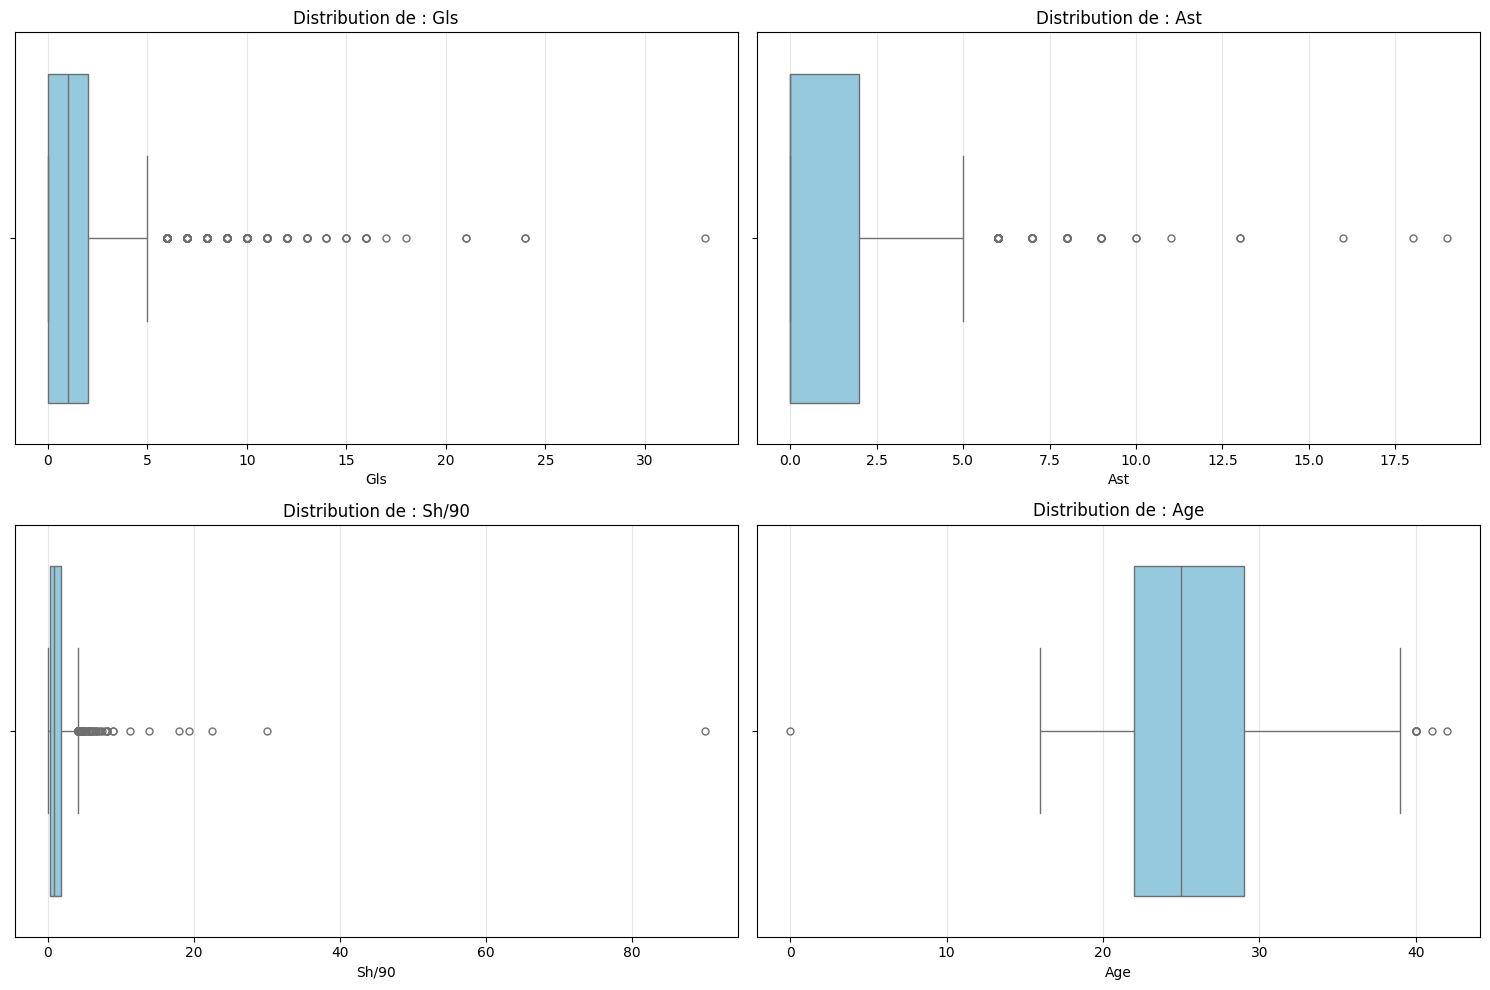

Top 5 'Outliers' Performance (Gls) :
              Player            Squad  Gls   Min
1279      Harry Kane    Bayern Munich   33  2152
1648   Kylian Mbappé      Real Madrid   24  2397
1066  Erling Haaland  Manchester City   24  2683
2508     Igor Thiago        Brentford   21  2922
1790    Vedat Muriqi         Mallorca   21  2678
----------------------------------------


In [14]:
# Lancement de l'audit sur ton dataset nettoyé
audit_fbref_outliers(df_fbref_final, metrics=['Gls', 'Ast', 'Sh/90', 'Age'])

## 3. Statsbomb - data qualité

### 1. Bilan des données StatsBomb

L'analyse des fichiers `.feather` permet de valider la structure des données de performance tactique. Nous analysons en effet 3464 matches qui peuvent présenter des incohérences dans les bases de données.

Nous ne trouvons cependant aucun doublon dans les données. Cependant, pour le moment, nous ne trouvons pas les compositions d'équipe peu importe le match. Les variables comparées sont sans doute légèrement différentes, il faudra donc régler ce problème pour trouver les joueurs présents dans les matches.



Malgré le problème de liaison, le volume par ligue est significatif et couvre bien le "Big Five" européen :

* **La Liga** : 868 matchs
* **Ligue 1** : 435 matchs
* **Premier League** : 418 matchs
* **Serie A** : 381 matchs
* **Bundesliga** : 340 matchs

In [15]:
# Définition du chemin (adapte selon ton architecture)
folder = Path("../data/statsbomb_datasets/data")

# 1. Chargement des fichiers Feather
df_sb_matches = pd.read_feather(folder / "all_matches.feather")
df_sb_lineups = pd.read_feather(folder / "all_lineups.feather")
df_sb_competitions = pd.read_feather(folder / "competitions_statsbomb.feather")

# 2. Exécution de l'Audit
stats_report = audit_statsbomb_data(df_sb_matches, df_sb_lineups)

AUDIT STATSBOMB
-------------------------------------------
• Matchs   : 3464 lignes | Doublons : 0
• Lineups  : 131901 lignes | Doublons : 0
• Intégrité: 3464 match(s) sans composition d'équipe
-------------------------------------------
Aucune valeur manquante sur les identifiants clés.

Top 5 Compétitions (StatsBomb) :
competition.competition_name
La Liga           868
Ligue 1           435
Premier League    418
Serie A           381
1. Bundesliga     340
Name: count, dtype: int64
-------------------------------------------


### 2. Analyse de la couverture temporelle

Cette analyse valide la profondeur historique du dataset **StatsBomb** après application d'un filtre analysant les matches à partir de 2020.


Le dataset filtré couvre plus de **5 ans** de données footballistiques, de juillet 2020 à juillet 2025, permettant de capturer les évolutions tactiques récentes.

Bien que le nombre total de matchs (760) soit inférieur à d'autres datasets, la qualité "événementielle" de StatsBomb compense cette quantité par une densité d'information supérieure (xG, pressions, positions).


On observe une accélération de la collecte de données sur les saisons civiles et les exercices récents.

| Saison | Nombre de Matchs |
| :--- | :---: |
| **2023** | 122 |
| **2024** | 83 |
| **2023/2024** | 34 |
| **2022/2023** | 32 |
| **2025** | 31 |

Il faudrait cependant normaliser les noms des saisons pour en tirer des conclusions.

In [16]:
# Analyse temporelle
sb_start, sb_end = check_statsbomb_temporal_coverage(df_sb_matches)

COUVERTURE TEMPORELLE STATSBOMB (Depuis 01/07/2020)
-------------------------------------------
• Premier match : 05/07/2020
• Dernier match  : 27/07/2025
• Étendue        : 1848 jours (env. 5.1 ans)
• Nb de matchs   : 760
-------------------------------------------

Matchs par Saison :
season.season_name
2025          31
2024          83
2023/2024     34
2023         122
2022/2023     32
Name: count, dtype: int64


### 3. Analyse Graphique StatsBomb


Le dataset est dominé par **La Liga**, suivie d'un volume équilibré pour les autres ligues du **Big Five** (Ligue 1, Premier League, Serie A, Bundesliga). La présence de compétitions internationales assure cependant une bonne diversité.


La distribution des buts suit une **loi de Poisson** cohérente : généralement, il y a 1 but par équipe et la courbe des scores à domicile est légèrement plus élevée et étendue que celle à l'extérieur. Les scores élevés sont rares, confirmant l'absence d'anomalies majeures.


Les données semblent alors **statistiquement saines**. La distribution des buts valide la fiabilité des résultats pour la modélisation.

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\exploration_statsbomb.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_matches, y='competition.competition_name',


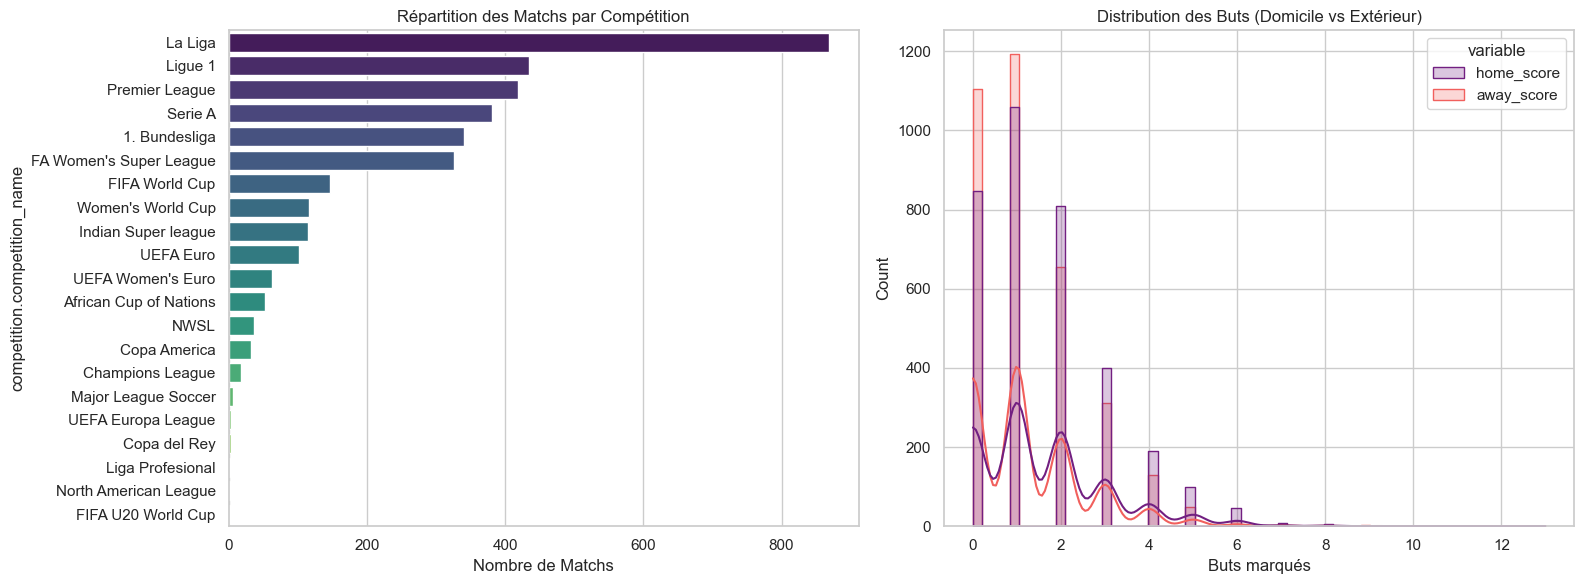

In [17]:
# 1. Visualisation des compétitions et des scores
plot_statsbomb_distributions(df_sb_matches)

## 4. football-data - data qualité

### 0. Source des Données et Traçabilité
Afin de garantir la reproductibilité de cette analyse, les données sont extraites directement via le site football-data.co.uk.

* **Dataset :** [Historical Football Results and Betting Odds Data](https://www.football-data.co.uk/data.php)
* **Dernière mise à jour du dataset :** 2026-05-04

Pour constater si nos données sont mises à jour régulièrement, nous pouvons regarder la date de dernière mise à jour.

In [18]:
# Vérification des mises à jour
df_status = check_football_data_updates(season="2526")

# Affichage élégant
display(df_status)

Vérification des mises à jour (Saison 2526)...



,Compétition,Code,Dernière mise à jour
0,Premier League,E0,"Mon, 04 May 2026 22:03:19 GMT"
1,Liga,SP1,"Mon, 04 May 2026 22:03:19 GMT"
2,Serie A,I1,"Mon, 04 May 2026 22:03:20 GMT"
3,Ligue 1,F1,"Sun, 03 May 2026 23:03:24 GMT"
4,Bundesliga,D1,"Sun, 03 May 2026 23:03:22 GMT"


### 1. Nettoyage des données

Le dataset a été filtré pour ne conserver que les indicateurs de performance et les cotes principales.

Ainsi, nous supprimons **85%** des colonnes inutiles. Les données sont prêtes pour être analysées.

In [19]:
# On charge avec low_memory=False car le fichier est large et hétérogène
df_fd_raw = pd.read_csv("../data/football_data.csv", low_memory=False)

# Nettoyage via la fonction
df_fd = process_football_data(df_fd_raw)

Audit Football-Data :
- Nombre de colonnes initiales : 163
- Nombre de colonnes après élagage : 25
- Matchs validés : 5117
------------------------------


### 2. Intégrité des données

L'audit de qualité final confirme la robustesse du dataset **Football-Data** après traitement. Les données sont structurellement saines et prêtes pour la phase de modélisation.

En effet, une seule ligne (1 match) présente des valeurs manquantes sur l'ensemble des statistiques de jeu (Tirs, Corners, Fautes, Cartons). De plus, aucun doublon n'a été détecté.

Aucune erreur de score, de résultat final ou encore de côte de paris sportifs n'a été détecté non plus.


Le dataset est considéré comme propre. L'absence totale d'erreurs de résultat et de doublons assure que le modèle ne subira aucun biais lié à des erreurs de saisie humaine dans la source de données.

In [20]:
df_na = audit_data_quality(df_fd)

Analyse qualité :
-------------------------------
• Doublons détectés : 0
-------------------------------
Colonnes avec données manquantes :
Variable  Nombre de NA
      HS             1
      AS             1
     HST             1
     AST             1
      HF             1
      AF             1
      HC             1
      AC             1
      HY             1
      AY             1
      HR             1
      AR             1
-------------------------------


In [21]:
# Lancement de l'audit final sur ton dataframe nettoyé
coherence_report = audit_football_data_coherence(df_fd)

Audit de cohérence terminé :
-------------------------------------------
• Erreurs de score (négatifs)  : 0
• Erreurs de résultat (FTR)    : 0
• Anomalies sur les cotes      : 0
• Matchs en double             : 0
-------------------------------------------
Intégrité des données : PARFAITE


### 3. Analyse de la Couverture et des Ligues

Ce dernier contrôle permet de valider l'équilibre du dataset et la profondeur historique disponible pour l'entraînement du modèle.

Le dataset couvre une période charnière de près de **3 ans**, incluant les saisons complètes depuis 2023/2024 et les matchs les plus récents de 2026. Cette durée est idéale pour capturer la saisonnalité et l'évolution à long terme des performances des clubs.


Les données sont équitablement réparties entre les **5 grands championnats européens (Big Five)**. La différence de volume (Bundesliga et Ligue 1) s'explique structurellement par le passage à **18 clubs** (34 journées contre 38 pour les autres ligues). Cette répartition reflète parfaitement la réalité du calendrier européen.


Les données sont **synchronisées, nommées et équilibrées**. Nous disposons d'une base solide de plus de 5 000 matchs pour débuter nos analyses statistiques.

In [22]:
# Vérification pour Football-Data
check_temporal_coverage(df_fd, 'Date')

Couverture temporelle [Date] :
  • Début : 11/08/2023
  • Fin   : 04/05/2026
  • Durée : 997 jours
-----------------------------------


(Timestamp('2023-08-11 00:00:00'), Timestamp('2026-05-04 00:00:00'))

In [23]:
# On applique la fonction sur ton dataset déjà chargé
df_fd = analyze_league_distribution(df_fd, league_col='Div')

Répartition par Compétition :
------------------------------
Div
Serie A           1110
Premier League    1109
Liga              1100
Bundesliga         900
Ligue 1            898
------------------------------
Total Matchs : 5117
